In [11]:
import cantera as ct
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
gas = ct.Solution("gri30_highT_inerts.yaml")

Reaction                | Index | Relative Rate
H2O2 + OH <=> H2O + HO2 | 88    | 1.00000
H + HNO <=> H2 + NO     | 213   | 0.03054
HO2 + OH <=> H2O + O2   | 286   | 0.02682
C3H8 + H <=> C3H7 + H2  | 313   | 0.02669
C2H2 + OH <=> H + HCCOH | 107   | 0.02632


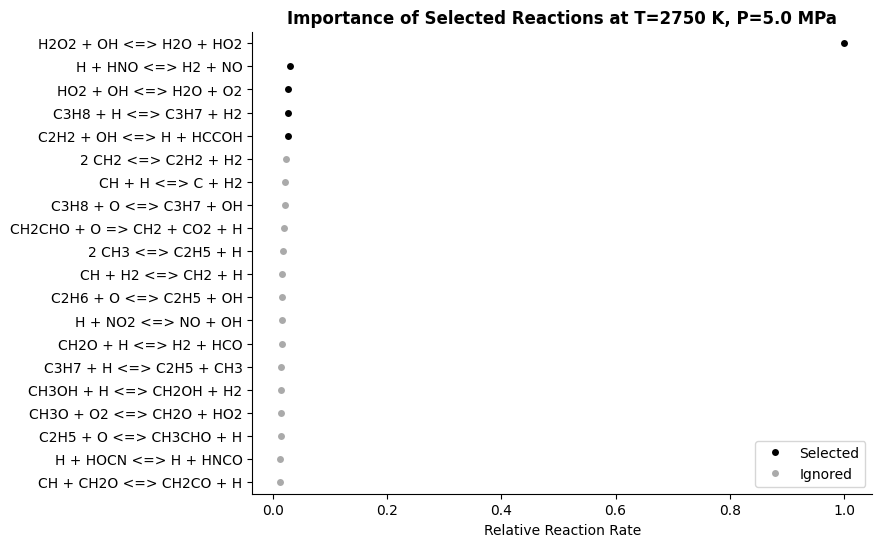

In [74]:
interesting = []
T = 2750  # K
P = 5e6  # Pa
gas.TP = T, P
rxns = gas.reactions()
for idx, r in enumerate(rxns):
    rxn_species = set(r.reactants).union(set(r.products))
    # if ("H" in rxn_species or "OH" in rxn_species) and ("CO2" in rxn_species or "N2" in rxn_species):
    interesting.append((r, idx, max(abs(gas.forward_rate_constants[idx]), abs(gas.reverse_rate_constants[idx]))))
interesting = sorted(interesting, key=lambda info: info[-1], reverse=True)

items = []
relative_importance = []
for item in interesting:
    items.append(item[0])
    relative_importance.append(item[2] / interesting[0][2])

top_n = 5
max_items = 20
fig, ax = plt.subplots(figsize=(8, 6))
is_important = ["Selected" if item in items[:top_n] else "Ignored" for item in items]
sns.set_palette(("#000000", "#AAAAAA"))
sns.stripplot(y=items[:max_items], x=relative_importance[:max_items], hue=is_important[:max_items], ax=ax)
ax.set_xlabel("Relative Reaction Rate")
ax.set_title(f"Importance of Selected Reactions at T={T} K, P={P / 1e6} MPa", weight="bold")
sns.despine(fig)

rxn_len = 0
for item in interesting[:top_n]:
    rxn_len = max(rxn_len, len(str(item[0])))

header = f"Reaction {' ' * (rxn_len - 8)}| Index | Relative Rate"
print(f"{header}\n{'=' * len(header)}")
for i, item in enumerate(interesting[:top_n]):
    print(f"{str(item[0]).ljust(rxn_len)} | {item[1]:<5} | {relative_importance[i]:1.5f}")

## TODO
- Simulate with no perturbation
- Store _ALL_ reaction rates across time
- Use this to figure out most important ones